In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
df = pd.read_csv(
    "../main_cities.csv",
    sep=",",
    header=0,
    names=["city_id", "latitude", "longitude", "population_est"]
)

nodes = df[["city_id", "latitude", "longitude", "population_est"]]

In [12]:
def _compute_distance(city_1, city_2):
    delta_long = city_1["longitude"] - city_2["longitude"]
    delta_lat = city_1["latitude"] - city_2["latitude"]
    dist = np.sqrt(delta_long**2 + delta_lat**2)
    return dist

df["distances"] = df.apply(
    lambda city: df.apply(lambda other: _compute_distance(city, other), axis=1).to_list(),
    axis=1
) 

df

,city_id,latitude,longitude,population_est,distances
0,0,31.529,35.094,706508,"[0.0, 0.2669868910639628, 0.7102562917707905, ..."
1,1,31.768,35.213,419108,"[0.2669868910639628, 0.0, 0.4548516241589074, ..."
2,2,32.221,35.254,380961,"[0.7102562917707905, 0.4548516241589074, 0.0, ..."
3,3,31.900,35.204,348110,"[0.38696382259844253, 0.1323064624271976, 0.32..."
4,4,32.459,35.300,311231,"[0.9525418625971273, 0.6964553108419828, 0.242..."
5,5,31.705,35.203,216114,"[0.2070193227696386, 0.06378871373527029, 0.51..."
6,6,32.312,35.027,182053,"[0.7858613109194246, 0.5749191247471218, 0.244..."
7,7,32.190,34.971,110800,"[0.6723466367878985, 0.48646479831535566, 0.28..."
8,8,32.083,35.180,70727,"[0.5606353538620251, 0.31672385448525764, 0.15..."
9,9,32.322,35.369,64719,"[0.839329494298874, 0.575544959147417, 0.15305..."


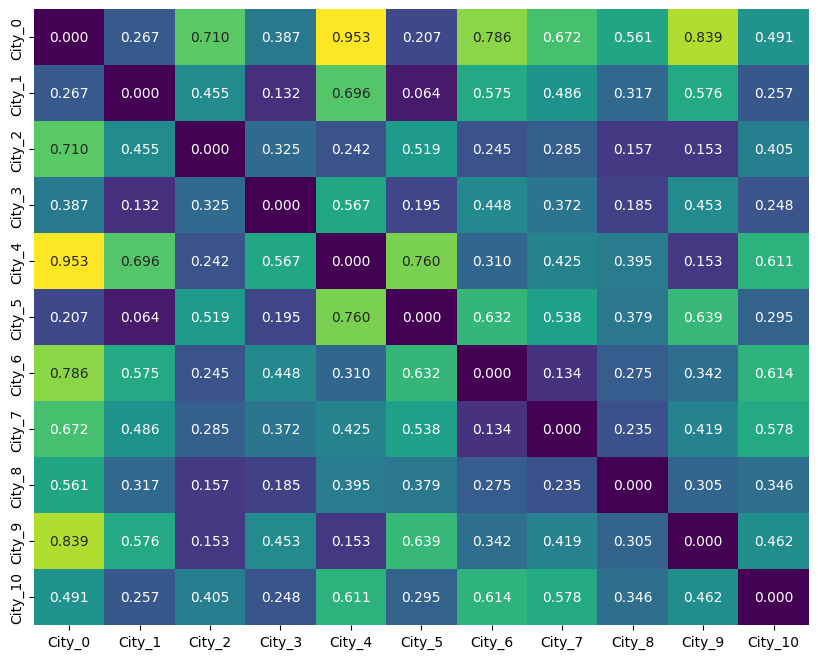

In [13]:
city_labels = [f"City_{i}" for i in df.index]

distance_table = pd.DataFrame(df["distances"].to_list(),index=city_labels,columns=city_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(distance_table,cmap="viridis",annot=True,fmt=".3f",cbar=False)
plt.show()

In [14]:
nodes = df[["latitude", "longitude", "population_est"]]

import random

random.seed(42)
edge_prob = 0.5

candidats = []
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        if random.random() < edge_prob:
            weight = random.randint(1, 10)
            candidats.append((i, j, weight))

edges_df = pd.DataFrame(candidats, columns=["from_city", "to_city", "weight"])
print(f"Generated {len(candidats)} random edges")
edges_df.head()

Generated 25 random edges


,from_city,to_city,weight
0,0,2,5
1,0,3,3
2,0,7,7
3,0,8,2
4,0,9,9


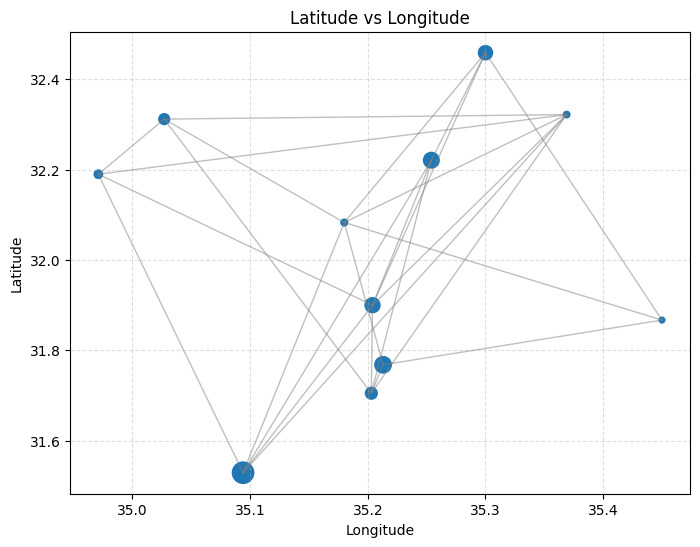

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    df["longitude"],
    df["latitude"],
    s=df["population_est"] / 3000
)

coords = df.set_index("city_id")[["longitude", "latitude"]]
for _, edge in edges_df.iterrows():
    x1, y1 = coords.loc[edge["from_city"]]
    x2, y2 = coords.loc[edge["to_city"]]
    plt.plot([x1, x2], [y1, y2], color="gray", alpha=0.5, linewidth=1)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Latitude vs Longitude")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [100]:
def objective_function(Xs, W):
    y = np.sum(np.dot(Xs, W))
    return y

def constrained_function(Xs, W, S=3, mu=1.0):
    y = np.sum(np.dot(Xs, W))
    constraint = mu*(np.sum(Xs)-S)**2
    return y-constraint

def flops(n):
    return 2*n**2+n+2

In [127]:
from math import degrees
def graph(n=None):

    df = pd.read_csv(
        "../cities_50largest.csv",
        sep=",",
        header=0,
        names=["city_id", "latitude", "longitude", "population_est"]
    )
    nodes = df[["city_id", "latitude", "longitude", "population_est"]]

    if n is not None:
        nodes = nodes[:n]

    limit_distance = 0.4
    def _compute_distance(city_1, city_2):
        delta_long = city_1["longitude"] - city_2["longitude"]
        delta_lat = city_1["latitude"] - city_2["latitude"]
        dist = np.sqrt(delta_long**2 + delta_lat**2)
        return dist

    edges = [[0.0 for _ in range(len(nodes))] for _ in range(len(nodes))]
    for i in range(len(nodes)):
        edges[i][i] = 1.0
        for j in range(i + 1, len(nodes)):
            if _compute_distance(nodes.iloc[i], nodes.iloc[j]) < limit_distance:
                edges[i][j] = 1.0
                edges[j][i] = 1.0
    
    degrees = [sum(row) for row in edges]
    degree = max(degrees)

    return nodes, edges, degree

In [128]:
import pickle
import time

full_dir = {}

for n in range(4, 20):
    print(f"n={n}\n")
    start_n = time.perf_counter()

    full_outs = {}
    _, w,degree = graph(n)
    mu_value = 1.1*degree
    S_value = n // 2
    print_idx = 0.1

    for i, xs in enumerate(itertools.product((0, 1), repeat=n)):
        if i >= int(2**n * print_idx):
            print(f"completed {int(print_idx*100)}%")
            print_idx += 0.1
        full_outs[xs] = constrained_function(xs, w, S=S_value, mu=mu_value)

    elapsed_n = time.perf_counter() - start_n
    full_outs["time"] = elapsed_n
    full_dir[n] = full_outs
    print(f"time for n={n}: {elapsed_n:.2f} seconds\n")

    # Save progress after each n
    with open("results/full_dir.pkl", "wb") as f:
        pickle.dump(full_dir, f)

n=4

completed 10%
completed 20%
completed 30%
completed 40%
completed 50%
completed 60%
completed 70%
completed 80%
completed 89%
completed 99%
time for n=4: 0.00 seconds

n=5

completed 10%
completed 20%
completed 30%
completed 40%
completed 50%
completed 60%
completed 70%
completed 80%
completed 89%
completed 99%
time for n=5: 0.00 seconds

n=6

completed 10%
completed 20%
completed 30%
completed 40%
completed 50%
completed 60%
completed 70%
completed 80%
completed 89%
completed 99%
time for n=6: 0.00 seconds

n=7

completed 10%
completed 20%
completed 30%
completed 40%
completed 50%
completed 60%
completed 70%
completed 80%
completed 89%
completed 99%
time for n=7: 0.01 seconds

n=8

completed 10%
completed 20%
completed 30%
completed 40%
completed 50%
completed 60%
completed 70%
completed 80%
completed 89%
completed 99%
time for n=8: 0.01 seconds

n=9

completed 10%
completed 20%
completed 30%
completed 40%
completed 50%
completed 60%
completed 70%
completed 80%
completed 89%
comp

In [196]:
restricted_dir = {}

for n in range(4, 20):
    print(f"n={n}\n")
    
    restricted_outs = {}
    _, w,_ = graph(n)
    S_value = n // 2
    print_idx = 0.1

    perms= itertools.product((0, 1), repeat=n)
    perms = (xs for xs in perms if sum(xs) <= S_value)
    
    start_n = time.perf_counter()
    for i, xs in enumerate(perms):
        if i >= int(2**n * print_idx):
            print(f"completed {int(print_idx*100)}%")
            print_idx += 0.1

        restricted_outs[xs] = objective_function(xs, w)
    
    elapsed_n = time.perf_counter() - start_n
    restricted_outs["time"] = elapsed_n
    print(f"time for n={n}: {elapsed_n:.2f} seconds\n")

    restricted_dir[n]=restricted_outs

    # Save progress after each n
    with open("results/restriced_dir.pkl", "wb") as f:
        pickle.dump(restricted_dir, f)

n=4

completed 10%
completed 20%
completed 30%
completed 40%
completed 50%
completed 60%
time for n=4: 0.00 seconds

n=5

completed 10%
completed 20%
completed 30%
completed 40%
time for n=5: 0.00 seconds

n=6

completed 10%
completed 20%
completed 30%
completed 40%
completed 50%
completed 60%
time for n=6: 0.00 seconds

n=7

completed 10%
completed 20%
completed 30%
completed 40%
time for n=7: 0.00 seconds

n=8

completed 10%
completed 20%
completed 30%
completed 40%
completed 50%
completed 60%
time for n=8: 0.00 seconds

n=9

completed 10%
completed 20%
completed 30%
completed 40%
time for n=9: 0.00 seconds

n=10

completed 10%
completed 20%
completed 30%
completed 40%
completed 50%
completed 60%
time for n=10: 0.01 seconds

n=11

completed 10%
completed 20%
completed 30%
completed 40%
time for n=11: 0.02 seconds

n=12

completed 10%
completed 20%
completed 30%
completed 40%
completed 50%
completed 60%
time for n=12: 0.05 seconds

n=13

completed 10%
completed 20%
completed 30%
compl

In [197]:
with open('results/full_dir.pkl', 'rb') as f:
    results_full = pickle.load(f)

with open('results/restriced_dir.pkl', 'rb') as f:
    results_restrict = pickle.load(f)

In [198]:
best_full={}
best_restrict ={}

for n in range(4,20):
    full_n = results_full[n]
    full_candidates = {k: v for k, v in full_n.items() if k != "time"}
    full_n_key, full_n_max = max(full_candidates.items(), key=lambda kv: kv[1])
    best_full[n]=[full_n_key, full_n_max]

    restrict_n = results_restrict[n]
    restrict_candidates = {k: v for k, v in restrict_n.items() if k != "time"}
    restrict_n_key, restrict_n_max = max(restrict_candidates.items(), key=lambda kv: kv[1])
    best_restrict[n]=[restrict_n_key, restrict_n_max]


In [199]:
best_restrict

{4: [(0, 0, 1, 1), np.float64(4.0)],
 5: [(0, 0, 1, 0, 1), np.float64(7.0)],
 6: [(0, 0, 1, 0, 1, 1), np.float64(13.0)],
 7: [(0, 0, 1, 0, 1, 1, 0), np.float64(13.0)],
 8: [(0, 0, 1, 0, 1, 1, 0, 1), np.float64(22.0)],
 9: [(0, 0, 1, 0, 1, 1, 0, 1, 0), np.float64(23.0)],
 10: [(0, 1, 1, 0, 1, 0, 0, 1, 0, 1), np.float64(32.0)],
 11: [(0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0), np.float64(34.0)],
 12: [(0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1), np.float64(46.0)],
 13: [(1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0), np.float64(51.0)],
 14: [(1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1), np.float64(66.0)],
 15: [(1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0), np.float64(69.0)],
 16: [(1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0), np.float64(77.0)],
 17: [(1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1), np.float64(85.0)],
 18: [(1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1),
  np.float64(105.0)],
 19: [(0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1),
  np.float64(114.0)]}

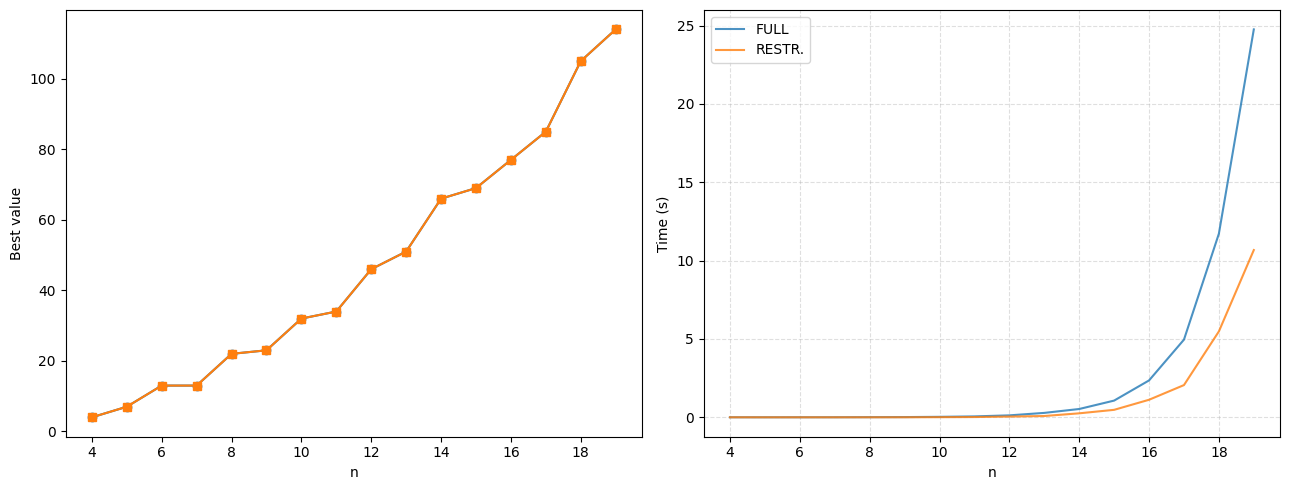

In [209]:
n_vals = sorted(set(best_full.keys()) & set(best_restrict.keys()))

full_vals = [float(best_full[n][1]) for n in n_vals]
full_times = [float(results_full[n]["time"]) for n in n_vals]

restrict_vals = [float(best_restrict[n][1]) for n in n_vals]
restrict_times = [float(results_restrict[n]["time"]) for n in n_vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(n_vals, full_vals, marker="o", label="FULL")
axes[0].plot(n_vals, restrict_vals, marker="s", label="RESTR.")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Best value")
axes[1].grid(True, linestyle="--", alpha=0.4)

axes[1].plot(n_vals, full_times, alpha=0.8, label="FULL")
axes[1].plot(n_vals, restrict_times, alpha=0.8, label="RESTR.")
axes[1].set_xlabel("n")
axes[1].set_ylabel("Time (s)")
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()